Quantum-Assisted Physics-Informed Neural Networks for Thermal and Flow Modeling in Electric Vehicle Battery Cooling Systems

In [41]:
!pip install pennylane

In [42]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import time
import psutil

Quantum-Assisted Physics-Informed Neural Networks for Thermal and Flow Modeling in Electric Vehicle Battery Cooling Systems

In [43]:
alpha = 1.0

print(alpha)

1.0


In [44]:
x_min = 0
x_max = 1

t_min = 0
t_max = 1

In [45]:
def initial_condition(x):
    return np.sin(np.pi*x)

In [46]:
def boundary_condition(x,t):
    return np.zeros_like(x)

Generate Training Points

In [47]:
N_f = 1000
N_b = 100
N_i = 100

x_f = np.random.rand(N_f,1)
t_f = np.random.rand(N_f,1)

x_b_left = np.zeros((N_b,1))
t_b_left = np.random.rand(N_b,1)

x_b_right = np.ones((N_b,1))
t_b_right = np.random.rand(N_b,1)

x_i = np.random.rand(N_i,1)
t_i = np.zeros((N_i,1)
)

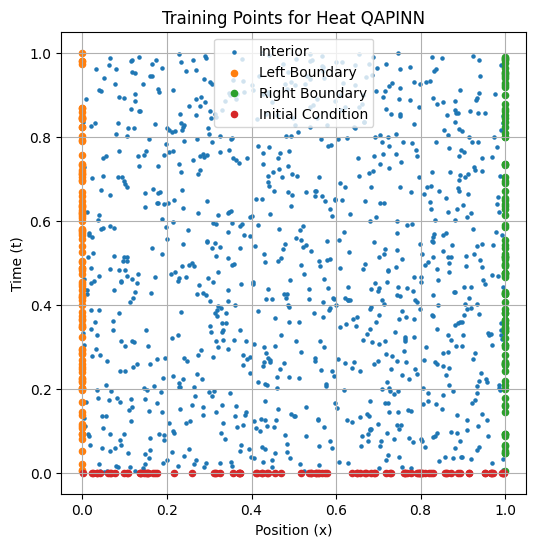

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Interior points
plt.scatter(x_f, t_f, s=5, label="Interior")

# Left boundary
plt.scatter(x_b_left, t_b_left, s=20, label="Left Boundary")

# Right boundary
plt.scatter(x_b_right, t_b_right, s=20, label="Right Boundary")

# Initial condition
plt.scatter(x_i, t_i, s=20, label="Initial Condition")

plt.xlabel("Position (x)")
plt.ylabel("Time (t)")
plt.title("Training Points for Heat QAPINN")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
import torch

# Interior points
x_f = torch.tensor(x_f, dtype=torch.float32, requires_grad=True)
t_f = torch.tensor(t_f, dtype=torch.float32, requires_grad=True)

# Initial condition
x_i = torch.tensor(x_i, dtype=torch.float32)
t_i = torch.tensor(t_i, dtype=torch.float32)

# Left boundary
x_b_left = torch.tensor(x_b_left, dtype=torch.float32)
t_b_left = torch.tensor(t_b_left, dtype=torch.float32)

# Right boundary
x_b_right = torch.tensor(x_b_right, dtype=torch.float32)
t_b_right = torch.tensor(t_b_right, dtype=torch.float32)

print("✅ Training data converted to PyTorch tensors.")

✅ Training data converted to PyTorch tensors.


In [50]:
# Number of qubits

n_qubits = 4

print(f"Number of Qubits = {n_qubits}")

Number of Qubits = 4


In [51]:
import pennylane as qml

# Create a quantum simulator

dev = qml.device(
    "default.qubit",
    wires=n_qubits
)

print("✅ Quantum Device Created Successfully!")

✅ Quantum Device Created Successfully!


In [52]:
@qml.qnode(dev, interface="torch")

def quantum_circuit(inputs, weights):

    # Encode classical data into qubits
    qml.AngleEmbedding(
        features=inputs,
        wires=range(n_qubits)
    )

    # Variational quantum layer
    qml.StronglyEntanglingLayers(
        weights=weights,
        wires=range(n_qubits)
    )

    # Measure each qubit
    for layer in range(n_layers):
        for wire in range(n_qubits):
            qml.RY(weights[layer, wire, 0], wires=wire)

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)
    ]

In [53]:
# Number of variational layers inside the quantum circuit
n_layers = 2

# Shape of trainable quantum weights
weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

print(weight_shapes)

{'weights': (2, 4, 3)}


In [54]:
# Convert quantum circuit into a PyTorch layer
quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)

print(quantum_layer)

<Quantum Torch Layer: func=quantum_circuit>


In [55]:
# Create one random sample
sample = torch.rand(4)

print("Input:")
print(sample)

output = quantum_layer(sample)

print("\nQuantum Output:")
print(output)

print("\nOutput Shape:", output.shape)

Input:
tensor([0.3664, 0.7862, 0.3552, 0.1816])

Quantum Output:
tensor([-0.0954,  0.1474, -0.4488,  0.0049], grad_fn=<ToCopyBackward0>)

Output Shape: torch.Size([4])


Define the QAPINN Model

In [56]:
class QAPINN(nn.Module):

    def __init__(self):
        super(QAPINN, self).__init__()

        # Classical input layer
        self.input_layer = nn.Linear(2, n_qubits)

        # Quantum layer
        self.quantum_layer = quantum_layer

        # Classical output layers
        self.hidden1 = nn.Linear(n_qubits, 20)
        self.hidden2 = nn.Linear(20, 20)
        self.output_layer = nn.Linear(20, 1)

        self.activation = nn.Tanh()

    def forward(self, x):

        # Classical preprocessing
        x = self.input_layer(x)
        x = self.activation(x)

        # Quantum layer
        x = self.quantum_layer(x)

        # Classical postprocessing
        x = self.hidden1(x)
        x = self.activation(x)

        x = self.hidden2(x)
        x = self.activation(x)

        x = self.output_layer(x)

        return x

In [57]:
qamodel = QAPINN()

print(qamodel)

QAPINN(
  (input_layer): Linear(in_features=2, out_features=4, bias=True)
  (quantum_layer): <Quantum Torch Layer: func=quantum_circuit>
  (hidden1): Linear(in_features=4, out_features=20, bias=True)
  (hidden2): Linear(in_features=20, out_features=20, bias=True)
  (output_layer): Linear(in_features=20, out_features=1, bias=True)
  (activation): Tanh()
)


In [58]:
total_params = sum(p.numel() for p in qamodel.parameters())

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 577


In [59]:
# One sample with (x, t)
sample = torch.rand(1, 2)

prediction = qamodel(sample)

print("Input:")
print(sample)

print("\nPredicted Temperature:")
print(prediction)

print("\nOutput Shape:", prediction.shape)

Input:
tensor([[0.0830, 0.8087]])

Predicted Temperature:
tensor([[-0.0230]], grad_fn=<AddmmBackward0>)

Output Shape: torch.Size([1, 1])


In [60]:
optimizer = torch.optim.Adam(
    qamodel.parameters(),
    lr=0.001
)

mse_loss = nn.MSELoss()

print("Optimizer Created Successfully!")

Optimizer Created Successfully!


Physics Loss

In [61]:
def physics_loss():

    inputs = torch.cat((x_f, t_f), dim=1)

    u = qamodel(inputs)

    u_t = torch.autograd.grad(
        u,
        t_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u,
        x_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x,
        x_f,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = u_t - alpha*u_xx

    return torch.mean(residual**2)

Initial Condition Loss

In [62]:
def initial_loss():

    inputs = torch.cat((x_i, t_i), dim=1)

    prediction = qamodel(inputs)

    target = torch.sin(torch.pi*x_i)

    return mse_loss(prediction, target)

Boundary Condition Loss

In [63]:
def boundary_loss():

    left_inputs = torch.cat((x_b_left, t_b_left), dim=1)
    right_inputs = torch.cat((x_b_right, t_b_right), dim=1)

    left_prediction = qamodel(left_inputs)
    right_prediction = qamodel(right_inputs)

    left_loss = mse_loss(
        left_prediction,
        torch.zeros_like(left_prediction)
    )

    right_loss = mse_loss(
        right_prediction,
        torch.zeros_like(right_prediction)
    )

    return left_loss + right_loss

Total Loss

In [64]:
def total_loss():

    return (
        physics_loss()
        + initial_loss()
        + boundary_loss()
    )

In [65]:
loss = total_loss()

print("Initial Loss:", loss.item())

Initial Loss: 0.4634742736816406


Train the **QAPINN**

In [66]:
# Number of training epochs
epochs = 2000

# Store loss values
loss_history = []

# Start timer
start_time = time.time()

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = total_loss()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss = {loss.item():.6f}")

# End timer
training_time = time.time() - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time: {training_time:.2f} seconds")

Epoch 0 | Loss = 0.463474
Epoch 200 | Loss = 0.143601
Epoch 400 | Loss = 0.096614
Epoch 600 | Loss = 0.060722
Epoch 800 | Loss = 0.041842
Epoch 1000 | Loss = 0.032710
Epoch 1200 | Loss = 0.026751
Epoch 1400 | Loss = 0.022580
Epoch 1600 | Loss = 0.016612
Epoch 1800 | Loss = 0.011539

Training Completed Successfully!
Training Time: 725.92 seconds


Plot Training **Loss**

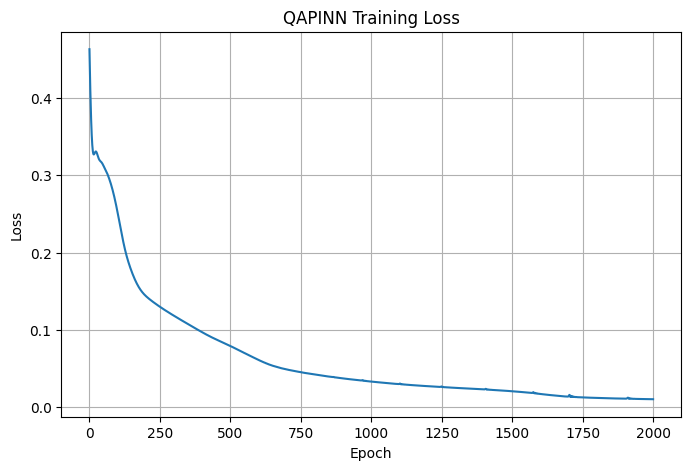

In [67]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("QAPINN Training Loss")

plt.grid(True)

plt.show()

In [68]:
qamodel.eval()

print("QAPINN is now in evaluation mode.")

QAPINN is now in evaluation mode.


Generate Test Grid

In [69]:
x_test = np.linspace(0,1,100)

t_test = np.linspace(0,1,100)

X, T = np.meshgrid(x_test, t_test)

X_flat = X.reshape(-1,1)

T_flat = T.reshape(-1,1)

print("Test grid generated.")

Test grid generated.


Convert Test Grid to Tensors

In [70]:
X_tensor = torch.tensor(
    X_flat,
    dtype=torch.float32
)

T_tensor = torch.tensor(
    T_flat,
    dtype=torch.float32
)

print("Test tensors created.")

Test tensors created.


Predict **Temperature**

In [71]:
test_inputs = torch.cat(
    (X_tensor, T_tensor),
    dim=1
)

with torch.no_grad():

    prediction = qamodel(test_inputs)

prediction = prediction.numpy()

U_pred = prediction.reshape(100,100)

print("Prediction completed.")

Prediction completed.


Temperature **Distribution** [ HEAT MAP]

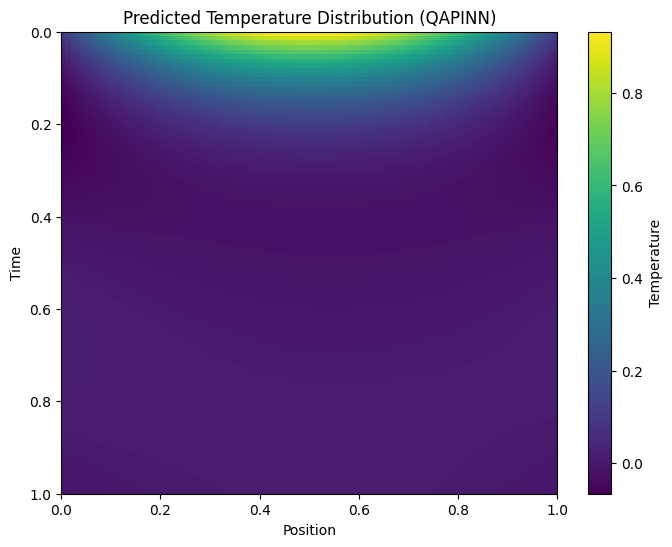

In [72]:
plt.figure(figsize=(8,6))

plt.imshow(
    U_pred,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar(label="Temperature")

plt.xlabel("Position")

plt.ylabel("Time")

plt.title("Predicted Temperature Distribution (QAPINN)")

plt.show()

PDE Residual **Error**

In [73]:
pde_error = physics_loss().item()

print("PDE Residual Error:", pde_error)

PDE Residual Error: 0.004181269556283951


Exact Heat Equation Solution

To compute Relative L2 Error, we need the analytical (true) solution.

For our Heat Equation:

u(x,t)=e
−π
2
αt
sin(πx)

In [74]:
U_exact = np.exp(-np.pi**2 * alpha * T) * np.sin(np.pi * X)

*Relative L2 Error* and training time  and count parameters

In [75]:
relative_l2 = np.linalg.norm(U_exact - U_pred) / np.linalg.norm(U_exact)

print("Relative L2 Error:", relative_l2)


print("Training Time:", training_time, "seconds")

total_parameters = sum(
    p.numel()
    for p in qamodel.parameters()
)

print("Trainable Parameters:", total_parameters)

Relative L2 Error: 0.14627429280438572
Training Time: 725.9158437252045 seconds
Trainable Parameters: 577


Memory Usage and Summary Table

In [76]:
import psutil
import os

process = psutil.Process(os.getpid())

memory = process.memory_info().rss / (1024**2)

print("Memory Usage:", round(memory,2), "MB")

results = {
    "Metric": [
        "PDE Residual Error",
        "Relative L2 Error",
        "Training Time (s)",
        "Trainable Parameters",
        "Memory Usage (MB)"
    ],
    "Value": [
        pde_error,
        relative_l2,
        training_time,
        total_parameters,
        memory
    ]
}

import pandas as pd

df = pd.DataFrame(results)

print(df)

Memory Usage: 831.29 MB
                 Metric       Value
0    PDE Residual Error    0.004181
1     Relative L2 Error    0.146274
2     Training Time (s)  725.915844
3  Trainable Parameters  577.000000
4     Memory Usage (MB)  831.289062


In [77]:
torch.save(
    qamodel.state_dict(),
    "heat_qapinn_model.pth"
)

print("Model Saved Successfully!")


df.to_csv(
    "heat_qapinn_results.csv",
    index=False
)

print("Results Saved Successfully!")

Model Saved Successfully!
Results Saved Successfully!


In [78]:
print("physics_loss" in globals())
print("initial_loss" in globals())
print("boundary_loss" in globals())
print("total_loss" in globals())
print("qamodel" in globals())

True
True
True
True
True


In [80]:
import pandas as pd

comparison = pd.DataFrame({

    "Qubits": [4],

    "PDE Residual Error": [pde_error],

    "Relative L2 Error": [relative_l2],

    "Training Time (s)": [training_time],

    "Memory Usage (MB)": [memory],

    "Trainable Parameters": [total_parameters]

})

comparison

,Qubits,PDE Residual Error,Relative L2 Error,Training Time (s),Memory Usage (MB),Trainable Parameters
0,4,0.004181,0.146274,725.915844,831.289062,577
